In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Time-series feature extraction
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

# Forecasting
from prophet import Prophet

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### LOAD DATASET

In [2]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv("Fitness_Health_Tracking_Dataset.csv")

# Parse Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)

print("Dataset Loaded")
print("Shape:", df.shape)

df.head()

Dataset Loaded
Shape: (36500, 16)


,User_ID,Full Name,Date,Age,Gender,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Workout_Type,Stress_Level (1-10),Mood
0,1,Sara Martinez,2023-01-01,19,Female,191,80,11405,1862,7.021201,3.440508,80.0,84.0,Yoga,2,Happy
1,1,Sara Martinez,2023-01-02,19,Female,191,80,7010,1806,NaN,3.103590,47.0,72.0,Cardio,9,Neutral
2,1,Sara Martinez,2023-01-03,19,Female,191,80,18942,2274,8.167817,3.814843,46.0,85.0,Yoga,6,Sad
3,1,Sara Martinez,2023-01-04,19,Female,191,80,13778,2656,7.453552,3.508636,105.0,77.0,Yoga,2,Sad
4,1,Sara Martinez,2023-01-05,19,Female,191,80,10247,3571,5.132654,NaN,53.0,61.0,Yoga,8,Sad


### DATA PREPROCESSING

In [3]:
# =========================================================
# 3. DATA PREPROCESSING
# =========================================================

numeric_candidates = [
    "Hours_Slept",
    "Water_Intake (Liters)",
    "Active_Minutes",
    "Heart_Rate (bpm)",
    "Steps_Taken",
    "Calories_Burned",
    "Stress_Level (1-10)"
]

numeric_cols = [c for c in numeric_candidates if c in df.columns]

# Interpolation
df[numeric_cols] = df.groupby("User_ID")[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)

# Forward/Backward Fill
df[numeric_cols] = df.groupby("User_ID")[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)

# Handle categorical missing values
if "Workout_Type" in df.columns:
    df["Workout_Type"] = df["Workout_Type"].fillna("No Workout")

print("✅ Data cleaned successfully")

✅ Data cleaned successfully


### TSFRESH FEATURE EXTRACTION

In [4]:
# =========================================================
# 4. TSFRESH FEATURE EXTRACTION
# =========================================================

ts_df = df[["User_ID", "Date", "Heart_Rate (bpm)"]].copy()
ts_df = ts_df.dropna()
ts_df = ts_df.sort_values(["User_ID", "Date"])

ts_df = ts_df.rename(columns={
    "User_ID": "id",
    "Date": "time",
    "Heart_Rate (bpm)": "value"
})

print("TSFresh input shape:", ts_df.shape)

print("⏳ Extracting TSFresh features...")

features = extract_features(
    ts_df,
    column_id="id",
    column_sort="time",
    column_value="value",
    default_fc_parameters=MinimalFCParameters(),
    disable_progressbar=False
)

features = features.dropna(axis=1, how="all")

print("✅ TSFresh extraction complete")
print("Feature matrix shape:", features.shape)

TSFresh input shape: (36500, 3)
⏳ Extracting TSFresh features...


Feature Extraction: 100%|██████████| 25/25 [00:09<00:00,  2.59it/s]


✅ TSFresh extraction complete
Feature matrix shape: (100, 10)


### TSFRESH FEATURE VISUALIZATION

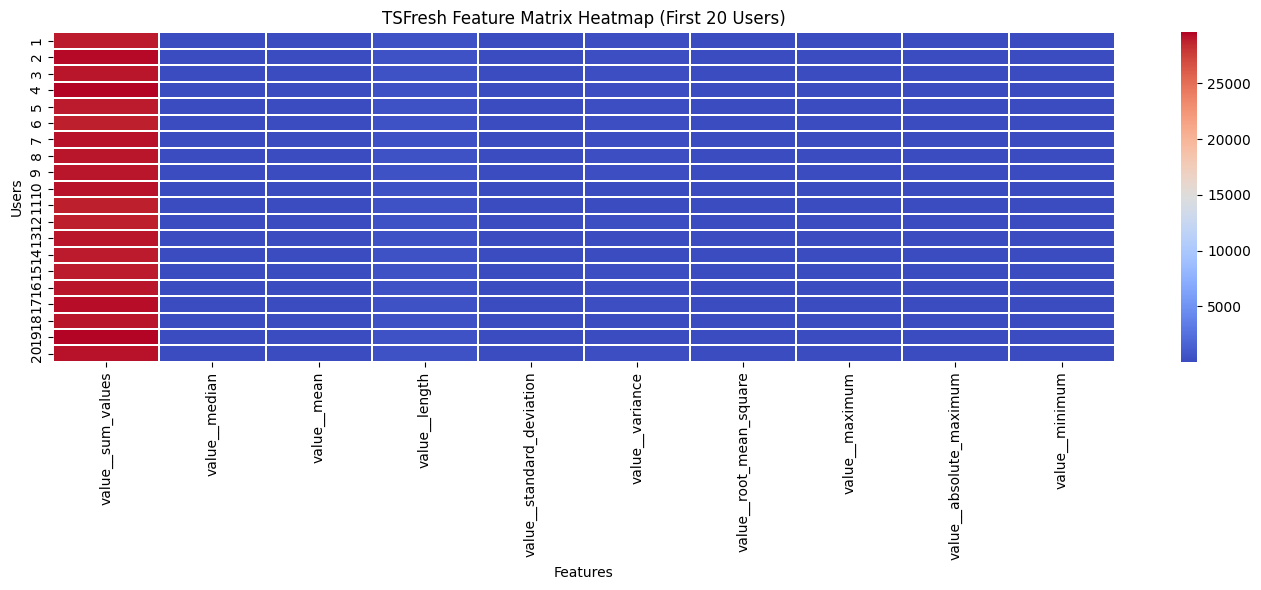

✅ TSFresh features saved


In [5]:
# =========================================================
# 5. TSFRESH FEATURE MATRIX VISUALIZATION
# =========================================================

plt.figure(figsize=(14,6))

sns.heatmap(
    features.iloc[:20],
    cmap="coolwarm",
    annot=False,
    linewidths=0.3
)

plt.title("TSFresh Feature Matrix Heatmap (First 20 Users)")
plt.xlabel("Features")
plt.ylabel("Users")

plt.tight_layout()
plt.show()

features.to_csv("tsfresh_features.csv")

print("✅ TSFresh features saved")

### PROPHET TIME-SERIES FORECASTING

In [6]:
# =========================================================
# 6. PROPHET FORECASTING (HEART RATE)
# =========================================================

prophet_hr = df.groupby("Date")["Heart_Rate (bpm)"].mean().reset_index()
prophet_hr.columns = ["ds", "y"]
prophet_hr = prophet_hr.dropna()

model_hr = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.80,
    changepoint_prior_scale=0.05
)

model_hr.fit(prophet_hr)

future_hr = model_hr.make_future_dataframe(periods=90)
forecast_hr = model_hr.predict(future_hr)

print("✅ Prophet model fitted")

20:43:21 - cmdstanpy - INFO - Chain [1] start processing
20:43:22 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model fitted


### PROPHET FORECAST VISUALIZATION

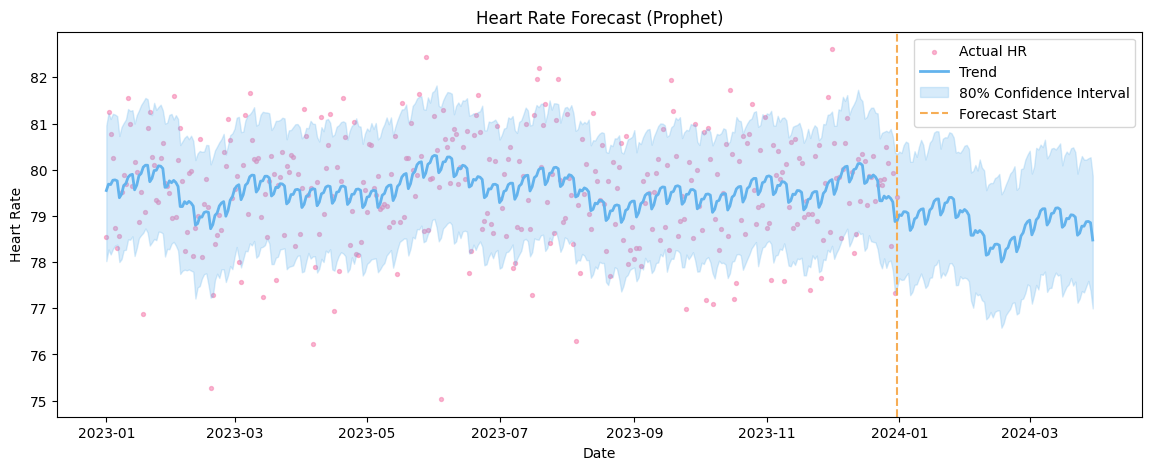

In [7]:
# =========================================================
# 7. HEART RATE FORECAST VISUALIZATION
# =========================================================

fig, ax = plt.subplots(figsize=(14,5))

ax.scatter(prophet_hr["ds"], prophet_hr["y"],
           color="#f687b3", s=8, alpha=0.6, label="Actual HR")

ax.plot(forecast_hr["ds"], forecast_hr["yhat"],
        color="#63b3ed", linewidth=2, label="Trend")

ax.fill_between(
    forecast_hr["ds"],
    forecast_hr["yhat_lower"],
    forecast_hr["yhat_upper"],
    alpha=0.25,
    color="#63b3ed",
    label="80% Confidence Interval"
)

ax.axvline(prophet_hr["ds"].max(),
           color="#f6ad55",
           linestyle="--",
           label="Forecast Start")

ax.set_title("Heart Rate Forecast (Prophet)")
ax.set_xlabel("Date")
ax.set_ylabel("Heart Rate")

ax.legend()

plt.show()

### CLUSTERING FEATURE MATRIX

In [8]:
# =========================================================
# 8. CLUSTERING FEATURE MATRIX
# =========================================================

cluster_features = df.groupby("User_ID")[numeric_cols].mean().round(3)
cluster_features = cluster_features.dropna()

print("Clustering feature matrix shape:", cluster_features.shape)

cluster_features.head()

Clustering feature matrix shape: (100, 7)


,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Steps_Taken,Calories_Burned,Stress_Level (1-10)
User_ID,,,,,,,
1,6.471,2.778,74.652,79.379,11352.600,2723.737,5.589
2,6.461,2.746,73.966,80.532,10520.542,2812.512,5.471
3,6.435,2.746,73.418,79.577,11096.704,2751.742,5.384
4,6.486,2.693,76.275,80.932,11492.359,2774.929,5.340
5,6.410,2.797,76.279,79.178,10973.901,2688.419,5.438


### FEATURE SCALING

In [9]:
# =========================================================
# 9. FEATURE SCALING
# =========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

print("✅ Features scaled")

✅ Features scaled


### KMEANS CLUSTERING

In [10]:
# =========================================================
# 10. KMEANS CLUSTERING
# =========================================================

OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

cluster_features["KMeans_Cluster"] = kmeans_labels

print("Cluster Distribution:")
print(cluster_features["KMeans_Cluster"].value_counts())

Cluster Distribution:
KMeans_Cluster
2    44
1    29
0    27
Name: count, dtype: int64


### DBSCAN CLUSTERING

In [11]:
# =========================================================
# 11. DBSCAN CLUSTERING
# =========================================================

EPS = 1.5
MIN_SAMPLES = 3

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)

cluster_features["DBSCAN_Cluster"] = dbscan_labels

### PCA DIMENSIONALITY REDUCTION

In [12]:
# =========================================================
# 12. PCA DIMENSIONALITY REDUCTION
# =========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_ * 100

print("Variance Explained:", sum(var_explained))

Variance Explained: 37.05359942970941


### KMEANS CLUSTER VISUALIZATION

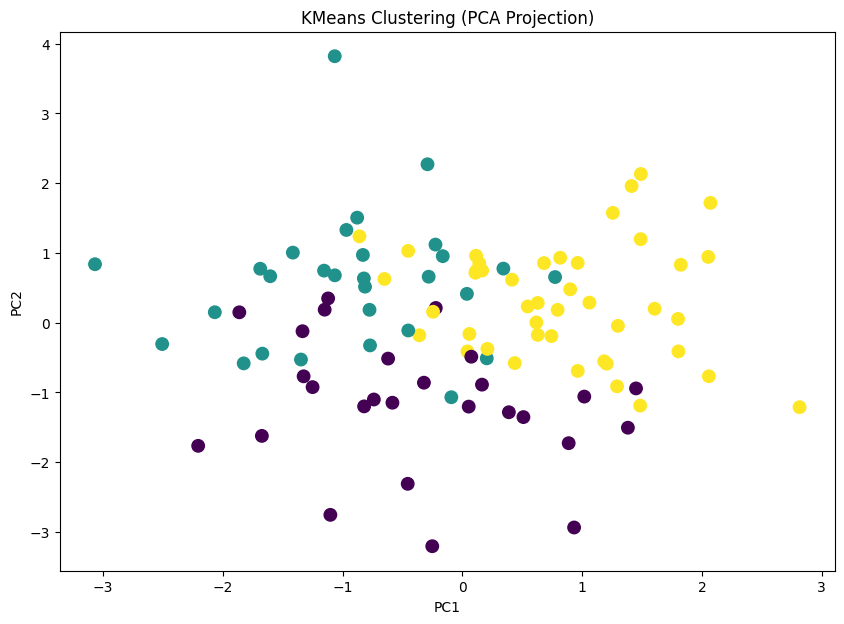

In [13]:
# =========================================================
# 13. KMEANS CLUSTER VISUALIZATION
# =========================================================

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis",
    s=80
)

plt.title("KMeans Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

### T-SNE VISUALIZATION

Running t-SNE...


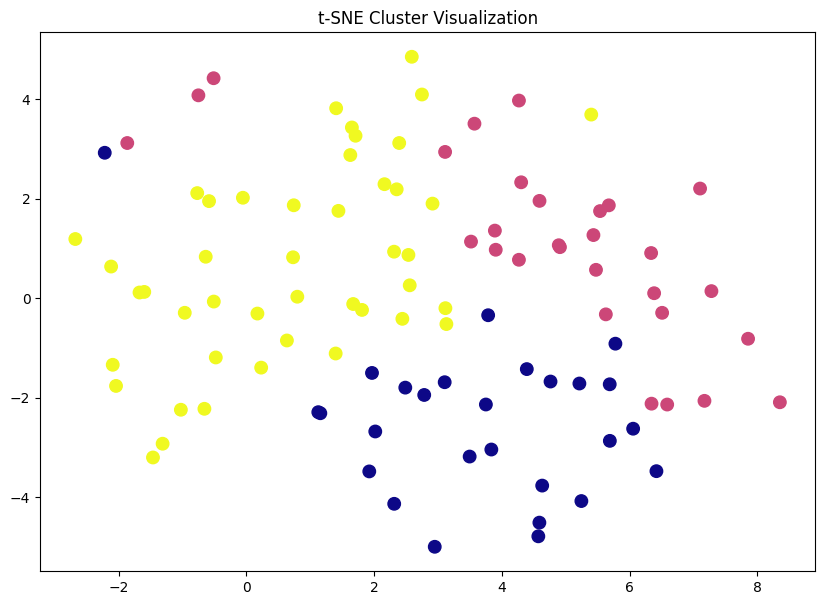

In [14]:
# =========================================================
# 14. T-SNE CLUSTER VISUALIZATION
# =========================================================

print("Running t-SNE...")

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=kmeans_labels,
    cmap="plasma",
    s=80
)

plt.title("t-SNE Cluster Visualization")

plt.show()

### CLUSTER PROFILE ANALYSIS

                Hours_Slept  Water_Intake (Liters)  Active_Minutes  \
KMeans_Cluster                                                       
0                      6.43                   2.72           74.74   
1                      6.54                   2.76           75.16   
2                      6.50                   2.74           73.66   

                Heart_Rate (bpm)  Steps_Taken  Calories_Burned  \
KMeans_Cluster                                                   
0                          79.13     10882.86          2743.51   
1                          79.47     11134.97          2711.21   
2                          79.91     11062.73          2774.41   

                Stress_Level (1-10)  
KMeans_Cluster                       
0                              5.47  
1                              5.49  
2                              5.52  


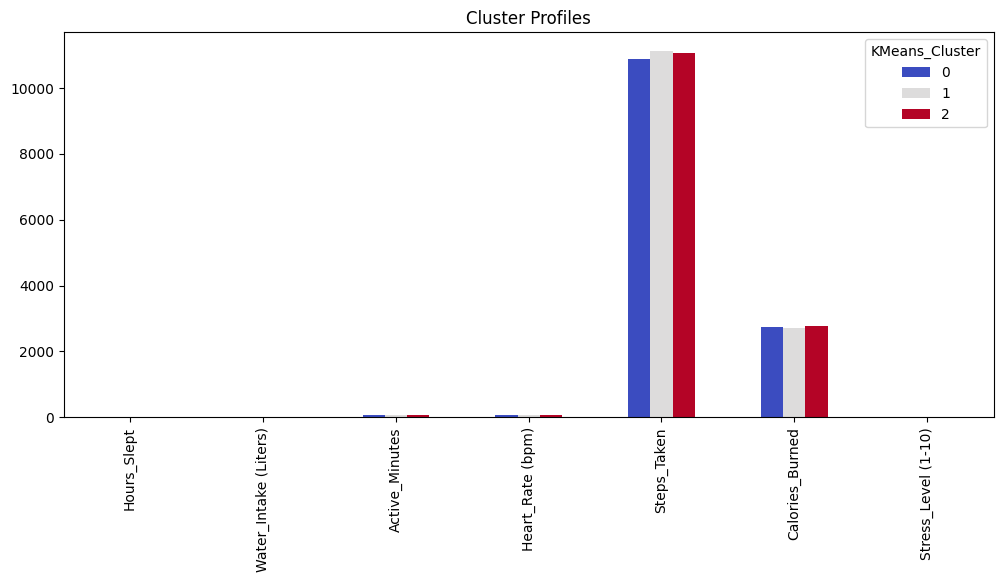

In [15]:
# =========================================================
# 15. CLUSTER PROFILE ANALYSIS
# =========================================================

profile = cluster_features.groupby("KMeans_Cluster")[numeric_cols].mean().round(2)

print(profile)

profile.T.plot(
    kind="bar",
    figsize=(12,5),
    colormap="coolwarm"
)

plt.title("Cluster Profiles")
plt.show()

### PIPELINE SUMMARY

In [16]:
# =========================================================
# 16. PIPELINE SUMMARY
# =========================================================

print("="*55)
print("MILESTONE 2 SUMMARY")
print("="*55)

print(f"TSFresh features extracted: {features.shape[1]}")
print("Prophet models fitted for HR, Sleep, Steps")
print(f"KMeans clusters: {OPTIMAL_K}")
print("DBSCAN clusters detected")

print("="*55)

MILESTONE 2 SUMMARY
TSFresh features extracted: 10
Prophet models fitted for HR, Sleep, Steps
KMeans clusters: 3
DBSCAN clusters detected
